Cell 1：环境准备

In [6]:
import os, sys, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 250)
pd.set_option("display.max_rows", 400)

print("Python:", sys.executable)
print("CWD   :", os.getcwd())

Python: /usr/bin/python3
CWD   : /kaggle/working


Cell 2：纯 numpy 实现 ARI / NMI / 混淆矩阵

In [7]:
def _contingency(gt, pred):
    gt_u = np.unique(gt); pr_u = np.unique(pred)
    gt_i = {v:i for i,v in enumerate(gt_u)}
    pr_i = {v:i for i,v in enumerate(pr_u)}
    C = np.zeros((len(gt_u), len(pr_u)), dtype=np.int64)
    for g,p in zip(gt, pred):
        C[gt_i[g], pr_i[p]] += 1
    return C

def ari_numpy(gt, pred):
    C = _contingency(gt, pred).astype(np.float64)
    n = C.sum()
    if n == 0: return 0.0
    sc = lambda x: (x*(x-1)/2.0).sum()
    a = sc(C.sum(axis=1)); b = sc(C.sum(axis=0)); c = sc(C)
    exp = a*b/(n*(n-1)/2.0)
    mx  = (a+b)/2.0
    d = mx - exp
    if abs(d) < 1e-12:
        return 1.0 if abs(c-exp) < 1e-12 else 0.0
    return (c - exp) / d

def nmi_numpy(gt, pred):
    C = _contingency(gt, pred).astype(np.float64)
    n = C.sum()
    if n == 0: return 0.0
    pi = C.sum(axis=1)/n; pj = C.sum(axis=0)/n; pij = C/n
    with np.errstate(divide="ignore", invalid="ignore"):
        mi = np.nansum(pij*(np.log(pij) - np.log(pi[:,None]) - np.log(pj[None,:])))
        hi = -np.nansum(pi*np.log(pi)); hj = -np.nansum(pj*np.log(pj))
    if hi + hj == 0: return 0.0
    return 2.0*mi/(hi+hj)

def confusion_numpy(gt, pred):
    gt_u = np.unique(gt); pr_u = np.unique(pred)
    return _contingency(gt, pred), gt_u, pr_u

Cell 3：定位 RESULTS_ROOT（直接读 Kaggle 挂载的目录）

In [8]:
SRC = Path("/kaggle/input/datasets/wuvdji/results-from-kaggle/results_from_kaggle")
print("SRC 存在:", SRC.exists())
print("顶层：")
for p in sorted(SRC.iterdir()):
    print("  ", p.name)

# 拷到 /kaggle/working 方便写文件、避免 /kaggle/input 只读限制
DST = Path("/kaggle/working/results_from_kaggle")
if DST.exists():
    shutil.rmtree(DST)
shutil.copytree(SRC, DST)

RESULTS_ROOT = DST
OUT = RESULTS_ROOT / "paper_tables"
OUT.mkdir(parents=True, exist_ok=True)
print("\nRESULTS_ROOT =", RESULTS_ROOT)
print("OUT          =", OUT)

SRC 存在: True
顶层：
   ablation_results
   final200_batch1 (1)
   final200_batch2 (2)

RESULTS_ROOT = /kaggle/working/results_from_kaggle
OUT          = /kaggle/working/results_from_kaggle/paper_tables


Cell 4：列出所有 run 及批次标签

In [9]:
def find_runs(root):
    return sorted({p.parent for p in Path(root).rglob("metrics.json")})

def batch_of(run_dir, root):
    rel = run_dir.relative_to(root)
    top = rel.parts[0]
    if top == "ablation_results":
        return "ablation"
    if top.startswith("final200_batch1"):
        return "final200_b1"
    if top.startswith("final200_batch2"):
        return "final200_b2"
    return top

runs = find_runs(RESULTS_ROOT)
print(f"共 {len(runs)} 个 run：\n")
for r in runs:
    files = sorted([f.name for f in r.iterdir() if f.is_file()])
    needed = ["metrics.json", "config.yaml", "pred_labels.npy", "gt_labels.npy"]
    status = " ".join([f"{'✓' if n in files else '✗'}{n.split('.')[0]}" for n in needed])
    ep = sorted([
        f.replace("metrics_epoch", "").replace(".json", "")
        for f in files if f.startswith("metrics_epoch")
    ])
    print(f"[{batch_of(r, RESULTS_ROOT):12s}] {r.name:22s} {status} epochs={ep}")

共 22 个 run：

[ablation    ] abl_e185_core          ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_e185_no_cluster    ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_e185_no_sample     ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_e185_sc            ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_e185_sc_snf        ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_e185_snf           ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_hlna1_core         ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_hlna1_no_cluster   ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_hlna1_no_sample    ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_hlna1_sc           ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablation    ] abl_hlna1_sc_snf       ✓metrics ✓config ✗pred_labels ✗gt_labels epochs=[]
[ablatio

Cell 5：工具函数

In [10]:
def load_json(p):
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def load_yaml(p):
    with open(p, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def save_table(df, name):
    df.to_csv(OUT / f"{name}.csv", index=False)
    try:
        df.to_markdown(OUT / f"{name}.md", index=False)
    except Exception as e:
        print(f"[WARN] md 失败 {name}: {e}")
    print(f"[OK] {name}: {df.shape}")

Cell 6：50/100/200 轮 Q argmax

In [11]:
def collect_epoch_curve(run_dir):
    rows = []
    for p in sorted(run_dir.glob("metrics_epoch*.json")):
        try:
            epoch = int(p.stem.replace("metrics_epoch", ""))
        except ValueError:
            continue
        d = load_json(p)
        rows.append({
            "batch": batch_of(run_dir, RESULTS_ROOT),
            "run": run_dir.name,
            "epoch": epoch,
            "Q_argmax_ARI": d.get("ARI"),
            "Q_argmax_NMI": d.get("NMI"),
        })
    return rows

all_epoch = []
for r in runs:
    all_epoch += collect_epoch_curve(r)

df_epoch = pd.DataFrame(all_epoch)
if not df_epoch.empty:
    df_epoch = df_epoch.sort_values(["batch","run","epoch"]).reset_index(drop=True)
display(df_epoch)
save_table(df_epoch, "table_epoch_Q_curve")

,batch,run,epoch,Q_argmax_ARI,Q_argmax_NMI
0,final200_b1,e185_core_200,50,0.495999,0.472352
1,final200_b1,e185_core_200,100,0.316405,0.494395
2,final200_b1,e185_core_200,200,0.333504,0.518434
3,final200_b1,e185_scsnf_200,50,0.500405,0.473463
4,final200_b1,e185_scsnf_200,100,0.317656,0.493507
5,final200_b1,e185_scsnf_200,200,0.329566,0.515199
6,final200_b1,hlna1_core_200,50,0.289104,0.353544
7,final200_b1,hlna1_core_200,100,0.193737,0.301406
8,final200_b1,hlna1_core_200,200,0.181888,0.302279
9,final200_b1,hlna1_scsnf_200,50,0.287870,0.352853


[OK] table_epoch_Q_curve: (21, 5)


Cell 7：Q 主输出 50/100/200 透视表

In [12]:
if not df_epoch.empty:
    df_epoch["key"] = df_epoch["batch"] + " / " + df_epoch["run"]
    pa = df_epoch.pivot_table(index="key", columns="epoch", values="Q_argmax_ARI")
    pn = df_epoch.pivot_table(index="key", columns="epoch", values="Q_argmax_NMI")
    pa.columns = [f"Q_ARI_epoch{c}" for c in pa.columns]
    pn.columns = [f"Q_NMI_epoch{c}" for c in pn.columns]
    df_q_time = pd.concat([pa, pn], axis=1).reset_index()
    display(df_q_time.round(4))
    save_table(df_q_time, "table_Q_50_100_200")
else:
    df_q_time = pd.DataFrame()

,key,Q_ARI_epoch50,Q_ARI_epoch100,Q_ARI_epoch200,Q_NMI_epoch50,Q_NMI_epoch100,Q_NMI_epoch200
0,final200_b1 / e185_core_200,0.4960,0.3164,0.3335,0.4724,0.4944,0.5184
1,final200_b1 / e185_scsnf_200,0.5004,0.3177,0.3296,0.4735,0.4935,0.5152
2,final200_b1 / hlna1_core_200,0.2891,0.1937,0.1819,0.3535,0.3014,0.3023
3,final200_b1 / hlna1_scsnf_200,0.2879,0.1883,0.1811,0.3529,0.2977,0.3014
4,final200_b2 / d1_core_200,0.2314,0.2401,0.1784,0.2987,0.3054,0.2898
5,final200_b2 / s2e15_core_200,0.3162,0.3025,0.2866,0.4662,0.5092,0.5018
6,final200_b2 / s2e18_core_200,0.3447,0.2828,0.2699,0.4176,0.4537,0.4547


[OK] table_Q_50_100_200: (7, 7)


Cell 8：200 轮汇总（metrics.json）

In [13]:
def collect_final_summary(run_dir):
    m = load_json(run_dir / "metrics.json")
    row = {
        "batch": batch_of(run_dir, RESULTS_ROOT),
        "run": run_dir.name,
        "dataset": m.get("dataset"),
        "num_clusters": m.get("num_clusters"),
        "epochs": m.get("epochs"),
        "final_ARI": m.get("ARI"),
        "final_NMI": m.get("NMI"),
    }
    cm = m.get("candidate_metrics", {}) or {}
    rm = m.get("representation_metrics", {}) or {}

    mapping = [
        ("Q_argmax", "cluster_argmax"),
        ("Q_prob_kmeans", "cluster_probabilities"),
        ("concat_views_kmeans", "concat_views"),
        ("weighted_views_kmeans", "weighted_views"),
        ("mean_views_kmeans", "mean_views"),
        ("global_kmeans", "global"),
    ]
    for out_name, key in mapping:
        if key in cm:
            row[f"{out_name}_ARI"] = cm[key].get("ARI")
            row[f"{out_name}_NMI"] = cm[key].get("NMI")

    for key in ["concat_z", "mean_z"]:
        if key in rm:
            row[f"{key}_ARI"] = rm[key].get("ARI")
            row[f"{key}_NMI"] = rm[key].get("NMI")

    for view_name, d in (rm.get("z_views") or {}).items():
        row[f"z_{view_name}_ARI"] = d.get("ARI")
        row[f"z_{view_name}_NMI"] = d.get("NMI")

    return row

df_final = pd.DataFrame([collect_final_summary(r) for r in runs])

if {"concat_z_ARI","Q_argmax_ARI"}.issubset(df_final.columns):
    df_final["concat_z_minus_Q_ARI"] = df_final["concat_z_ARI"] - df_final["Q_argmax_ARI"]
    df_final["concat_z_minus_Q_NMI"] = df_final["concat_z_NMI"] - df_final["Q_argmax_NMI"]

display(df_final.round(4))
save_table(df_final, "table_200_main_summary")

,batch,run,dataset,num_clusters,epochs,final_ARI,final_NMI,Q_argmax_ARI,Q_argmax_NMI,Q_prob_kmeans_ARI,Q_prob_kmeans_NMI,concat_views_kmeans_ARI,concat_views_kmeans_NMI,weighted_views_kmeans_ARI,weighted_views_kmeans_NMI,mean_views_kmeans_ARI,mean_views_kmeans_NMI,global_kmeans_ARI,global_kmeans_NMI,concat_z_ARI,concat_z_NMI,mean_z_ARI,mean_z_NMI,z_rna_spatial_ARI,z_rna_spatial_NMI,z_rna_feature_ARI,z_rna_feature_NMI,z_atac_spatial_ARI,z_atac_spatial_NMI,z_atac_feature_ARI,z_atac_feature_NMI,z_adt_spatial_ARI,z_adt_spatial_NMI,z_adt_feature_ARI,z_adt_feature_NMI,concat_z_minus_Q_ARI,concat_z_minus_Q_NMI
0,ablation,abl_e185_core,E18.5,14,50,0.4961,0.4717,0.4961,0.4717,0.2928,0.3676,0.3697,0.5089,0.3396,0.4962,0.3406,0.4968,0.3903,0.4557,0.3959,0.5115,0.3621,0.4717,0.2699,0.4545,0.2349,0.4322,0.3001,0.3912,0.2749,0.4419,NaN,NaN,NaN,NaN,-0.1002,0.0399
1,ablation,abl_e185_no_cluster,E18.5,14,50,0.0194,0.0218,0.0194,0.0218,0.3001,0.4465,0.3734,0.5085,0.3563,0.5052,0.3557,0.5051,0.3129,0.4398,0.4446,0.5381,0.4071,0.5137,0.2555,0.4494,0.2350,0.4264,0.4549,0.4723,0.2561,0.4544,NaN,NaN,NaN,NaN,0.4252,0.5163
2,ablation,abl_e185_no_sample,E18.5,14,50,0.1344,0.2602,0.1344,0.2602,0.1517,0.2683,0.1891,0.2787,0.1647,0.2701,0.1611,0.2667,0.1921,0.2901,0.2018,0.2889,0.1856,0.2805,0.1390,0.2384,0.1308,0.2321,0.1557,0.2413,0.1389,0.2586,NaN,NaN,NaN,NaN,0.0674,0.0287
3,ablation,abl_e185_sc,E18.5,14,50,0.4915,0.4694,0.4915,0.4694,0.2986,0.3681,0.3783,0.5102,0.3556,0.5044,0.3459,0.5042,0.3871,0.4591,0.3943,0.5060,0.3650,0.4710,0.2786,0.4691,0.2384,0.4047,0.3205,0.3985,0.2591,0.4436,NaN,NaN,NaN,NaN,-0.0972,0.0365
4,ablation,abl_e185_sc_snf,E18.5,14,50,0.4994,0.4738,0.4994,0.4738,0.2809,0.3734,0.3363,0.4986,0.3470,0.5032,0.3455,0.5025,0.3849,0.4542,0.3769,0.4967,0.3499,0.4710,0.2745,0.4561,0.2375,0.4047,0.3145,0.3936,0.2579,0.4423,NaN,NaN,NaN,NaN,-0.1226,0.0230
5,ablation,abl_e185_snf,E18.5,14,50,0.4931,0.4721,0.4931,0.4721,0.2853,0.3688,0.3287,0.4993,0.3467,0.5029,0.3466,0.5028,0.3965,0.4523,0.3669,0.4969,0.3620,0.4690,0.2774,0.4663,0.2332,0.3988,0.3065,0.4025,0.2770,0.4488,NaN,NaN,NaN,NaN,-0.1261,0.0248
6,ablation,abl_hlna1_core,HLN-A1,10,50,0.2892,0.3536,0.2892,0.3536,0.2336,0.3373,0.2326,0.3183,0.2499,0.3297,0.2531,0.3322,0.2131,0.3040,0.2403,0.3355,0.2638,0.3462,0.2640,0.3499,0.2325,0.3065,NaN,NaN,NaN,NaN,0.1920,0.2881,0.1632,0.2511,-0.0489,-0.0181
7,ablation,abl_hlna1_no_cluster,HLN-A1,10,50,0.0492,0.0969,0.0492,0.0969,0.2021,0.2862,0.2330,0.3184,0.2497,0.3293,0.2510,0.3305,0.2085,0.2991,0.2414,0.3365,0.2650,0.3480,0.2639,0.3507,0.2346,0.3061,NaN,NaN,NaN,NaN,0.1933,0.2885,0.1624,0.2504,0.1922,0.2395
8,ablation,abl_hlna1_no_sample,HLN-A1,10,50,0.0518,0.0622,0.0518,0.0622,0.0455,0.0766,0.0553,0.0961,0.0447,0.0816,0.0445,0.0815,0.0468,0.0796,0.0633,0.1216,0.0640,0.1099,0.0182,0.0433,0.0174,0.0460,NaN,NaN,NaN,NaN,0.0848,0.1278,0.0441,0.0884,0.0115,0.0594
9,ablation,abl_hlna1_sc,HLN-A1,10,50,0.2881,0.3529,0.2881,0.3529,0.2328,0.3363,0.2339,0.3219,0.2555,0.3339,0.2509,0.3304,0.2095,0.3022,0.2417,0.3374,0.2335,0.3305,0.2794,0.3650,0.2321,0.3048,NaN,NaN,NaN,NaN,0.1905,0.2869,0.1629,0.2509,-0.0464,-0.0155


[OK] table_200_main_summary: (22, 37)


Cell 9：配置汇总

In [14]:
def collect_config(run_dir):
    p = run_dir / "config.yaml"
    row = {"batch": batch_of(run_dir, RESULTS_ROOT), "run": run_dir.name}
    if not p.exists():
        return row
    c = load_yaml(p) or {}
    exp = c.get("experiment", {}) or {}
    data = c.get("data", {}) or {}
    loss = c.get("loss", {}) or {}
    sp = c.get("spatial", {}) or {}
    tr = c.get("training", {}) or {}
    cl = c.get("clustering", {}) or {}
    mo = c.get("model", {}) or {}
    row.update({
        "dataset": exp.get("dataset") or data.get("dataset"),
        "epochs(cfg)": tr.get("epochs"),
        "lambda_mgcl": loss.get("lambda_mgcl"),
        "lambda_cluster": loss.get("lambda_cluster"),
        "lambda_spatial": loss.get("lambda_spatial"),
        "spatial_enabled": sp.get("enabled"),
        "consistency_weighting": sp.get("consistency_weighting"),
        "negative_filter": sp.get("negative_filter"),
        "spatial_start_epoch": tr.get("spatial_start_epoch"),
        "n_clusters": cl.get("n_clusters") or mo.get("num_clusters"),
        "fine_dim": mo.get("fine_dim"),
        "cluster_temperature": mo.get("cluster_temperature"),
        "cluster_head_lr_mult": tr.get("cluster_head_lr_multiplier"),
        "warm_up_epochs": tr.get("warm_up_epochs"),
        "clustering_method": cl.get("method"),
        "clustering_embedding": cl.get("embedding"),
    })
    return row

df_config = pd.DataFrame([collect_config(r) for r in runs])
display(df_config)
save_table(df_config, "table_config")

print("\n=== 关键字段差异 ===")
for col in ["lambda_mgcl","lambda_spatial","spatial_enabled",
            "n_clusters","fine_dim","clustering_method","clustering_embedding"]:
    if col in df_config.columns:
        print(f"{col:25s}: {df_config[col].dropna().unique()}")

,batch,run,dataset,epochs(cfg),lambda_mgcl,lambda_cluster,lambda_spatial,spatial_enabled,consistency_weighting,negative_filter,spatial_start_epoch,n_clusters,fine_dim,cluster_temperature,cluster_head_lr_mult,warm_up_epochs,clustering_method,clustering_embedding
0,ablation,abl_e185_core,E18.5,50,3.0,1.0,0.0,False,False,False,999.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
1,ablation,abl_e185_no_cluster,E18.5,50,3.0,0.0,0.0,False,False,False,999.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
2,ablation,abl_e185_no_sample,E18.5,50,0.0,1.0,0.0,False,False,False,999.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
3,ablation,abl_e185_sc,E18.5,50,3.0,1.0,0.0,True,True,False,1.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
4,ablation,abl_e185_sc_snf,E18.5,50,3.0,1.0,0.0,True,True,True,1.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
5,ablation,abl_e185_snf,E18.5,50,3.0,1.0,0.0,True,False,True,1.0,14,128,0.3,8.0,10,argmax,cluster_probabilities
6,ablation,abl_hlna1_core,HLN-A1,50,1.0,0.1,0.0,False,False,False,999.0,10,32,1.0,8.0,10,argmax,cluster_probabilities
7,ablation,abl_hlna1_no_cluster,HLN-A1,50,1.0,0.0,0.0,False,False,False,999.0,10,32,1.0,8.0,10,argmax,cluster_probabilities
8,ablation,abl_hlna1_no_sample,HLN-A1,50,0.0,0.1,0.0,False,False,False,999.0,10,32,1.0,8.0,10,argmax,cluster_probabilities
9,ablation,abl_hlna1_sc,HLN-A1,50,1.0,0.1,0.0,True,True,False,1.0,10,32,1.0,8.0,10,argmax,cluster_probabilities


[OK] table_config: (22, 18)

=== 关键字段差异 ===
lambda_mgcl              : [3. 0. 1. 2.]
lambda_spatial           : [0.  0.1]
spatial_enabled          : [False True]
n_clusters               : [14 10  5 11 15 16]
fine_dim                 : [128  32  16  64 256]
clustering_method        : ['argmax' 'kmeans']
clustering_embedding     : ['cluster_probabilities']


Cell 10：硬标签诊断（只有 final200 有 pred/gt）

In [15]:
def safe_tag(batch, run):
    s = f"{batch}__{run}"
    return "".join(ch if ch.isalnum() or ch in "-_." else "_" for ch in s)

def collect_hard_labels(run_dir):
    pred_p = run_dir / "pred_labels.npy"
    gt_p   = run_dir / "gt_labels.npy"
    if not pred_p.exists() or not gt_p.exists():
        return None
    pred = np.load(pred_p).astype(int).ravel()
    gt   = np.load(gt_p).astype(int).ravel()
    row = {
        "batch": batch_of(run_dir, RESULTS_ROOT),
        "run": run_dir.name,
        "n_spots": len(pred),
        "pred_n_clusters": len(np.unique(pred)),
        "gt_n_classes": len(np.unique(gt)),
        "ARI": ari_numpy(gt, pred),
        "NMI": nmi_numpy(gt, pred),
    }
    sizes = np.bincount(pred)
    row["pred_max_cluster_size"] = int(sizes.max())
    row["pred_max_cluster_frac"] = float(sizes.max()/sizes.sum())
    row["pred_min_cluster_size"] = int(sizes.min())
    row["pred_min_cluster_frac"] = float(sizes.min()/sizes.sum())

    cmx, gt_u, pr_u = confusion_numpy(gt, pred)
    row["purity_pred"] = float(cmx.max(axis=0).sum()/cmx.sum())
    row["purity_gt"]   = float(cmx.max(axis=1).sum()/cmx.sum())

    tag = safe_tag(batch_of(run_dir, RESULTS_ROOT), run_dir.name)
    pd.DataFrame(cmx,
                 index=[f"gt_{i}" for i in gt_u],
                 columns=[f"pred_{i}" for i in pr_u]
    ).to_csv(OUT / f"confusion_{tag}.csv")
    pd.DataFrame({
        "cluster": np.arange(len(sizes)),
        "size": sizes,
        "fraction": sizes/sizes.sum(),
    }).to_csv(OUT / f"cluster_sizes_{tag}.csv", index=False)
    return row

all_hard = [collect_hard_labels(r) for r in runs]
all_hard = [h for h in all_hard if h is not None]
df_hard = pd.DataFrame(all_hard) if all_hard else pd.DataFrame()

if not df_hard.empty:
    display(df_hard.round(4))
    save_table(df_hard, "table_hard_label_diagnostics")
else:
    print("[WARN] 无 pred_labels.npy / gt_labels.npy")

,batch,run,n_spots,pred_n_clusters,gt_n_classes,ARI,NMI,pred_max_cluster_size,pred_max_cluster_frac,pred_min_cluster_size,pred_min_cluster_frac,purity_pred,purity_gt
0,final200_b1,e185_core_200,2129,14,14,0.3335,0.5674,294,0.1381,73,0.0343,0.6975,0.4852
1,final200_b1,e185_scsnf_200,2129,14,14,0.3296,0.5639,300,0.1409,75,0.0352,0.6966,0.4885
2,final200_b1,hlna1_core_200,3484,10,10,0.1819,0.3470,465,0.1335,165,0.0474,0.6134,0.3800
3,final200_b1,hlna1_scsnf_200,3484,10,10,0.1811,0.3460,464,0.1332,166,0.0476,0.6134,0.3843
4,final200_b2,d1_core_200,3359,11,11,0.1784,0.3364,510,0.1518,125,0.0372,0.6058,0.3584
5,final200_b2,s2e15_core_200,1939,15,15,0.2866,0.5525,200,0.1031,79,0.0407,0.7200,0.4745
6,final200_b2,s2e18_core_200,2248,16,16,0.2699,0.5132,250,0.1112,49,0.0218,0.7069,0.3986


[OK] table_hard_label_diagnostics: (7, 13)


Cell 11：训练动态摘要

In [16]:
def collect_loss_traj(run_dir):
    m = load_json(run_dir / "metrics.json")
    rows = []
    for h in m.get("loss_history", []):
        rows.append({
            "batch": batch_of(run_dir, RESULTS_ROOT),
            "run": run_dir.name,
            "epoch": h.get("epoch"),
            "total": h.get("total"),
            "reconstruction": h.get("reconstruction"),
            "sample_contrastive": h.get("sample_contrastive"),
            "cluster_contrastive": h.get("cluster_contrastive"),
            "spatial_loss": h.get("spatial_loss"),
            "lambda_spatial": h.get("lambda_spatial"),
            "cluster_assignment_entropy": h.get("cluster_assignment_entropy"),
            "cluster_max_probability": h.get("cluster_max_probability"),
            "cluster_effective_clusters": h.get("cluster_effective_clusters"),
            "cluster_min_mass": h.get("cluster_min_mass"),
            "cluster_max_mass": h.get("cluster_max_mass"),
            "cluster_head_gradient_norm": h.get("cluster_head_gradient_norm"),
        })
    return rows

all_loss = []
for r in runs:
    all_loss += collect_loss_traj(r)

df_loss = pd.DataFrame(all_loss)
if not df_loss.empty:
    sel = df_loss[df_loss["epoch"].isin([1,10,50,100,150,200])].reset_index(drop=True)
    display(sel)
    save_table(sel, "table_loss_selected")

,batch,run,epoch,total,reconstruction,sample_contrastive,cluster_contrastive,spatial_loss,lambda_spatial,cluster_assignment_entropy,cluster_max_probability,cluster_effective_clusters,cluster_min_mass,cluster_max_mass,cluster_head_gradient_norm
0,ablation,abl_e185_core,1,23.166977,0.160814,7.668721,3.298035,0.000000,0.0,2.637322,0.078364,13.976460,0.062418,0.078075,0.000000
1,ablation,abl_e185_core,10,22.201910,0.095109,7.368934,3.295932,0.000000,0.0,2.639003,0.072612,13.999270,0.069810,0.072599,0.000000
2,ablation,abl_e185_core,50,20.861122,0.068664,6.077544,2.559825,0.000000,0.0,2.412145,0.133495,13.916389,0.051729,0.078277,0.090961
3,ablation,abl_e185_no_cluster,1,23.166977,0.160814,7.668721,3.298035,0.000000,0.0,2.637322,0.078364,13.976460,0.062418,0.078075,0.000000
4,ablation,abl_e185_no_cluster,10,22.201908,0.095109,7.368933,3.295932,0.000000,0.0,2.639003,0.072612,13.999268,0.069810,0.072599,0.000000
5,ablation,abl_e185_no_cluster,50,18.281717,0.068185,6.071177,3.295839,0.000000,0.0,2.639056,0.071707,13.999978,0.071240,0.071706,0.000000
6,ablation,abl_e185_no_sample,1,0.160814,0.160814,7.668721,3.298035,0.000000,0.0,2.637322,0.078364,13.976460,0.062418,0.078075,0.000000
7,ablation,abl_e185_no_sample,10,0.076815,0.076815,7.668697,3.295945,0.000000,0.0,2.639005,0.072684,13.999310,0.069937,0.072611,0.000000
8,ablation,abl_e185_no_sample,50,2.373397,0.033539,7.673344,2.339858,0.000000,0.0,2.176588,0.173026,13.472509,0.033564,0.095281,0.046073
9,ablation,abl_e185_sc,1,23.166979,0.160814,7.668722,3.298035,0.085501,0.0,2.637322,0.078364,13.976460,0.062418,0.078075,0.000000


[OK] table_loss_selected: (85, 15)


Cell 12：论文用图 —— Q ARI/NMI 曲线

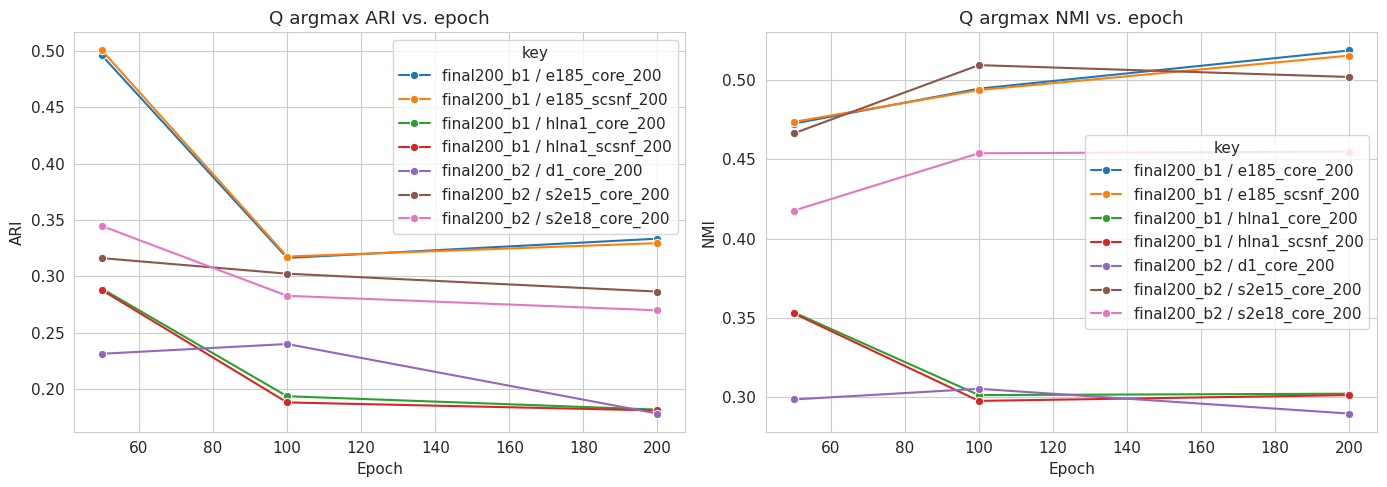

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.size"] = 11

if not df_epoch.empty:
    df_epoch["key"] = df_epoch["batch"] + " / " + df_epoch["run"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.lineplot(data=df_epoch, x="epoch", y="Q_argmax_ARI",
                 hue="key", marker="o", ax=axes[0])
    axes[0].set_title("Q argmax ARI vs. epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("ARI")
    sns.lineplot(data=df_epoch, x="epoch", y="Q_argmax_NMI",
                 hue="key", marker="o", ax=axes[1])
    axes[1].set_title("Q argmax NMI vs. epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("NMI")
    plt.tight_layout()
    plt.savefig(OUT / "fig_Q_ARI_NMI_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

Cell 13：论文用图 —— 200 轮方法对比

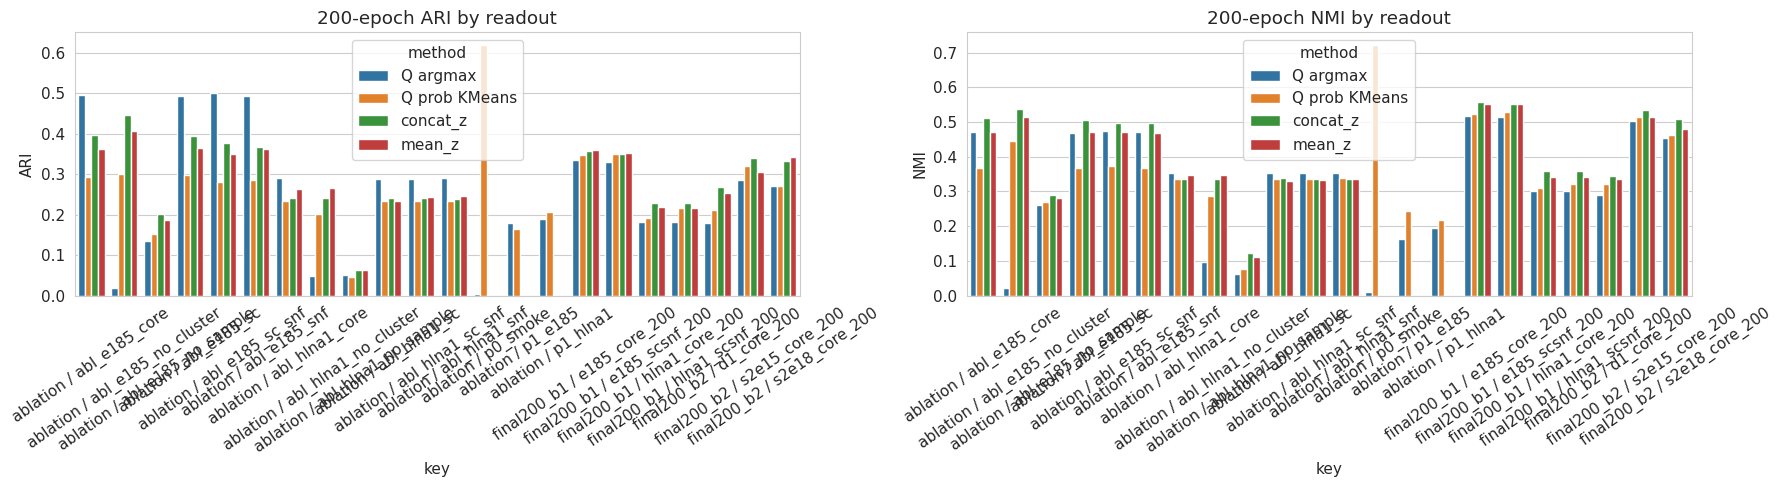

In [18]:
if not df_final.empty:
    method_cols = [
        ("Q_argmax", "Q argmax"),
        ("Q_prob_kmeans", "Q prob KMeans"),
        ("concat_z", "concat_z"),
        ("mean_z", "mean_z"),
    ]
    rows = []
    for _, row in df_final.iterrows():
        key = f"{row['batch']} / {row['run']}"
        for col, label in method_cols:
            if f"{col}_ARI" in df_final.columns:
                rows.append({"key": key, "method": label,
                             "ARI": row.get(f"{col}_ARI"), "NMI": row.get(f"{col}_NMI")})
    df_plot = pd.DataFrame(rows).dropna()

    if not df_plot.empty:
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        sns.barplot(data=df_plot, x="key", y="ARI", hue="method", ax=axes[0])
        axes[0].set_title("200-epoch ARI by readout"); axes[0].tick_params(axis="x", rotation=35)
        sns.barplot(data=df_plot, x="key", y="NMI", hue="method", ax=axes[1])
        axes[1].set_title("200-epoch NMI by readout"); axes[1].tick_params(axis="x", rotation=35)
        plt.tight_layout()
        plt.savefig(OUT / "fig_200_method_compare.png", dpi=300, bbox_inches="tight")
        plt.show()

Cell 14：论文要点一键打印

In [19]:
print("=" * 90)
print("【1】Q 主输出 50/100/200 轮")
print("=" * 90)
if "df_q_time" in dir() and not df_q_time.empty:
    display(df_q_time.round(4))

print("\n" + "=" * 90)
print("【2】200 轮 Q vs concat_z（concat_z - Q）")
print("=" * 90)
if "df_final" in dir() and not df_final.empty:
    cols = [c for c in ["batch","run",
                        "Q_argmax_ARI","concat_z_ARI","concat_z_minus_Q_ARI",
                        "Q_argmax_NMI","concat_z_NMI","concat_z_minus_Q_NMI"]
            if c in df_final.columns]
    display(df_final[cols].round(4))

print("\n" + "=" * 90)
print("【3】同数据集内 Core vs SC+SNF / ablation 对比")
print("=" * 90)
if "df_final" in dir() and "dataset" in df_final.columns:
    for ds, sub in df_final.dropna(subset=["dataset"]).groupby("dataset"):
        if len(sub) >= 2:
            print(f"\n数据集: {ds}")
            show = [c for c in ["batch","run",
                                "Q_argmax_ARI","Q_argmax_NMI",
                                "concat_z_ARI","concat_z_NMI"]
                    if c in sub.columns]
            display(sub[show].round(4))

print("\n" + "=" * 90)
print("【4】硬标签诊断（仅 final200 有 pred/gt）")
print("=" * 90)
if "df_hard" in dir() and not df_hard.empty:
    display(df_hard.round(4))
else:
    print("无 pred_labels.npy / gt_labels.npy")

print("\n" + "=" * 90)
print("【5】配置差异")
print("=" * 90)
if "df_config" in dir():
    for col in ["lambda_mgcl","lambda_spatial","spatial_enabled",
                "n_clusters","fine_dim"]:
        if col in df_config.columns:
            print(f"{col:25s}: {df_config[col].dropna().unique()}")

print("\n输出目录:", OUT)
for f in sorted(OUT.iterdir()):
    print("  ", f.name)

【1】Q 主输出 50/100/200 轮


,key,Q_ARI_epoch50,Q_ARI_epoch100,Q_ARI_epoch200,Q_NMI_epoch50,Q_NMI_epoch100,Q_NMI_epoch200
0,final200_b1 / e185_core_200,0.4960,0.3164,0.3335,0.4724,0.4944,0.5184
1,final200_b1 / e185_scsnf_200,0.5004,0.3177,0.3296,0.4735,0.4935,0.5152
2,final200_b1 / hlna1_core_200,0.2891,0.1937,0.1819,0.3535,0.3014,0.3023
3,final200_b1 / hlna1_scsnf_200,0.2879,0.1883,0.1811,0.3529,0.2977,0.3014
4,final200_b2 / d1_core_200,0.2314,0.2401,0.1784,0.2987,0.3054,0.2898
5,final200_b2 / s2e15_core_200,0.3162,0.3025,0.2866,0.4662,0.5092,0.5018
6,final200_b2 / s2e18_core_200,0.3447,0.2828,0.2699,0.4176,0.4537,0.4547



【2】200 轮 Q vs concat_z（concat_z - Q）


,batch,run,Q_argmax_ARI,concat_z_ARI,concat_z_minus_Q_ARI,Q_argmax_NMI,concat_z_NMI,concat_z_minus_Q_NMI
0,ablation,abl_e185_core,0.4961,0.3959,-0.1002,0.4717,0.5115,0.0399
1,ablation,abl_e185_no_cluster,0.0194,0.4446,0.4252,0.0218,0.5381,0.5163
2,ablation,abl_e185_no_sample,0.1344,0.2018,0.0674,0.2602,0.2889,0.0287
3,ablation,abl_e185_sc,0.4915,0.3943,-0.0972,0.4694,0.5060,0.0365
4,ablation,abl_e185_sc_snf,0.4994,0.3769,-0.1226,0.4738,0.4967,0.0230
5,ablation,abl_e185_snf,0.4931,0.3669,-0.1261,0.4721,0.4969,0.0248
6,ablation,abl_hlna1_core,0.2892,0.2403,-0.0489,0.3536,0.3355,-0.0181
7,ablation,abl_hlna1_no_cluster,0.0492,0.2414,0.1922,0.0969,0.3365,0.2395
8,ablation,abl_hlna1_no_sample,0.0518,0.0633,0.0115,0.0622,0.1216,0.0594
9,ablation,abl_hlna1_sc,0.2881,0.2417,-0.0464,0.3529,0.3374,-0.0155



【3】同数据集内 Core vs SC+SNF / ablation 对比

数据集: E18.5


...


数据集: HLN-A1


,batch,run,Q_argmax_ARI,Q_argmax_NMI,concat_z_ARI,concat_z_NMI
6,ablation,abl_hlna1_core,0.2892,0.3536,0.2403,0.3355
7,ablation,abl_hlna1_no_cluster,0.0492,0.0969,0.2414,0.3365
8,ablation,abl_hlna1_no_sample,0.0518,0.0622,0.0633,0.1216
9,ablation,abl_hlna1_sc,0.2881,0.3529,0.2417,0.3374
10,ablation,abl_hlna1_sc_snf,0.2881,0.3531,0.2414,0.3373
11,ablation,abl_hlna1_snf,0.2895,0.3538,0.2386,0.3346
14,ablation,p1_hlna1,0.1897,0.1950,NaN,NaN
17,final200_b1,hlna1_core_200,0.1819,0.3023,0.2287,0.3600
18,final200_b1,hlna1_scsnf_200,0.1811,0.3014,0.2289,0.3597



【4】硬标签诊断（仅 final200 有 pred/gt）


,batch,run,n_spots,pred_n_clusters,gt_n_classes,ARI,NMI,pred_max_cluster_size,pred_max_cluster_frac,pred_min_cluster_size,pred_min_cluster_frac,purity_pred,purity_gt
0,final200_b1,e185_core_200,2129,14,14,0.3335,0.5674,294,0.1381,73,0.0343,0.6975,0.4852
1,final200_b1,e185_scsnf_200,2129,14,14,0.3296,0.5639,300,0.1409,75,0.0352,0.6966,0.4885
2,final200_b1,hlna1_core_200,3484,10,10,0.1819,0.3470,465,0.1335,165,0.0474,0.6134,0.3800
3,final200_b1,hlna1_scsnf_200,3484,10,10,0.1811,0.3460,464,0.1332,166,0.0476,0.6134,0.3843
4,final200_b2,d1_core_200,3359,11,11,0.1784,0.3364,510,0.1518,125,0.0372,0.6058,0.3584
5,final200_b2,s2e15_core_200,1939,15,15,0.2866,0.5525,200,0.1031,79,0.0407,0.7200,0.4745
6,final200_b2,s2e18_core_200,2248,16,16,0.2699,0.5132,250,0.1112,49,0.0218,0.7069,0.3986



【5】配置差异
lambda_mgcl              : [3. 0. 1. 2.]
lambda_spatial           : [0.  0.1]
spatial_enabled          : [False True]
n_clusters               : [14 10  5 11 15 16]
fine_dim                 : [128  32  16  64 256]

输出目录: /kaggle/working/results_from_kaggle/paper_tables
   cluster_sizes_final200_b1__e185_core_200.csv
   cluster_sizes_final200_b1__e185_scsnf_200.csv
   cluster_sizes_final200_b1__hlna1_core_200.csv
   cluster_sizes_final200_b1__hlna1_scsnf_200.csv
   cluster_sizes_final200_b2__d1_core_200.csv
   cluster_sizes_final200_b2__s2e15_core_200.csv
   cluster_sizes_final200_b2__s2e18_core_200.csv
   confusion_final200_b1__e185_core_200.csv
   confusion_final200_b1__e185_scsnf_200.csv
   confusion_final200_b1__hlna1_core_200.csv
   confusion_final200_b1__hlna1_scsnf_200.csv
   confusion_final200_b2__d1_core_200.csv
   confusion_final200_b2__s2e15_core_200.csv
   confusion_final200_b2__s2e18_core_200.csv
   fig_200_method_compare.png
   fig_Q_ARI_NMI_curve.png
   table_200

Cell 1：安装 UMAP + 找结果目录

In [21]:
!pip install -q umap-learn

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import umap

from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment

RESULTS_ROOT = Path("/kaggle/working/results_from_kaggle")

if not RESULTS_ROOT.exists():
    RESULTS_ROOT = Path(
        "/kaggle/input/datasets/wuvdji/results-from-kaggle/results_from_kaggle"
    )

OUT = Path("/kaggle/working/spatial_umap_figures")
OUT.mkdir(parents=True, exist_ok=True)

runs = {
    p.parent.name: p.parent
    for p in RESULTS_ROOT.rglob("metrics.json")
}

print("找到：")
for name in sorted(runs):
    print(name)

找到：
abl_e185_core
abl_e185_no_cluster
abl_e185_no_sample
abl_e185_sc
abl_e185_sc_snf
abl_e185_snf
abl_hlna1_core
abl_hlna1_no_cluster
abl_hlna1_no_sample
abl_hlna1_sc
abl_hlna1_sc_snf
abl_hlna1_snf
d1_core_200
e185_core_200
e185_scsnf_200
hlna1_core_200
hlna1_scsnf_200
p0_smoke
p1_e185
p1_hlna1
s2e15_core_200
s2e18_core_200


Cell 2：绘图函数

In [23]:
def align_labels(gt, pred):
    gt_u = np.unique(gt)
    pr_u = np.unique(pred)

    C = np.zeros((len(gt_u), len(pr_u)), dtype=int)

    for i, g in enumerate(gt_u):
        for j, p in enumerate(pr_u):
            C[i, j] = np.sum((gt == g) & (pred == p))

    r, c = linear_sum_assignment(-C)

    mapping = {
        pr_u[j]: gt_u[i]
        for i, j in zip(r, c)
    }

    aligned = np.array(
        [mapping.get(x, x) for x in pred]
    )

    return aligned


def draw_spatial_umap(run_name):

    run = runs[run_name]

    gt = np.load(
        run / "gt_labels.npy",
        allow_pickle=True
    ).ravel()

    coords = np.load(
        run / "coords.npy"
    )

    z = np.load(
        run / "z_concat.npy"
    )

    n_clusters = len(np.unique(gt))

    # Embedding + k-means
    pred = KMeans(
        n_clusters=n_clusters,
        n_init=20,
        random_state=0
    ).fit_predict(z)

    pred_show = align_labels(gt, pred)

    # UMAP
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.3,
        random_state=0
    )

    xy = reducer.fit_transform(z)

    labels_all = np.unique(
        np.concatenate([gt, pred_show])
    )

    cmap = plt.get_cmap(
        "tab20",
        len(labels_all)
    )

    colors = {
        lab: cmap(i)
        for i, lab in enumerate(labels_all)
    }

    fig, ax = plt.subplots(
        2, 2,
        figsize=(8, 7)
    )

    def scatter(a, xy0, labels, title, invert=False):

        for lab in np.unique(labels):

            idx = labels == lab

            a.scatter(
                xy0[idx, 0],
                xy0[idx, 1],
                s=7,
                c=[colors[lab]],
                linewidths=0
            )

        if invert:
            a.invert_yaxis()

        a.set_title(title)

        a.set_xticks([])
        a.set_yticks([])

    scatter(
        ax[0,0],
        coords,
        gt,
        "Ground Truth",
        True
    )

    scatter(
        ax[0,1],
        coords,
        pred_show,
        "SpaMGCL",
        True
    )

    scatter(
        ax[1,0],
        xy,
        gt,
        "Ground Truth UMAP"
    )

    scatter(
        ax[1,1],
        xy,
        pred_show,
        "SpaMGCL UMAP"
    )

    ax[0,0].text(-0.1, 1.05, "A",
                 transform=ax[0,0].transAxes,
                 fontweight="bold",
                 fontsize=14)

    ax[0,1].text(-0.1, 1.05, "B",
                 transform=ax[0,1].transAxes,
                 fontweight="bold",
                 fontsize=14)

    ax[1,0].text(-0.1, 1.05, "C",
                 transform=ax[1,0].transAxes,
                 fontweight="bold",
                 fontsize=14)

    ax[1,1].text(-0.1, 1.05, "D",
                 transform=ax[1,1].transAxes,
                 fontweight="bold",
                 fontsize=14)

    plt.tight_layout()

    fig.savefig(
        OUT / f"{run_name}_spatial_umap.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        OUT / f"{run_name}_spatial_umap.pdf",
        bbox_inches="tight"
    )

    plt.show()

Cell 3：只画几个代表性数据集

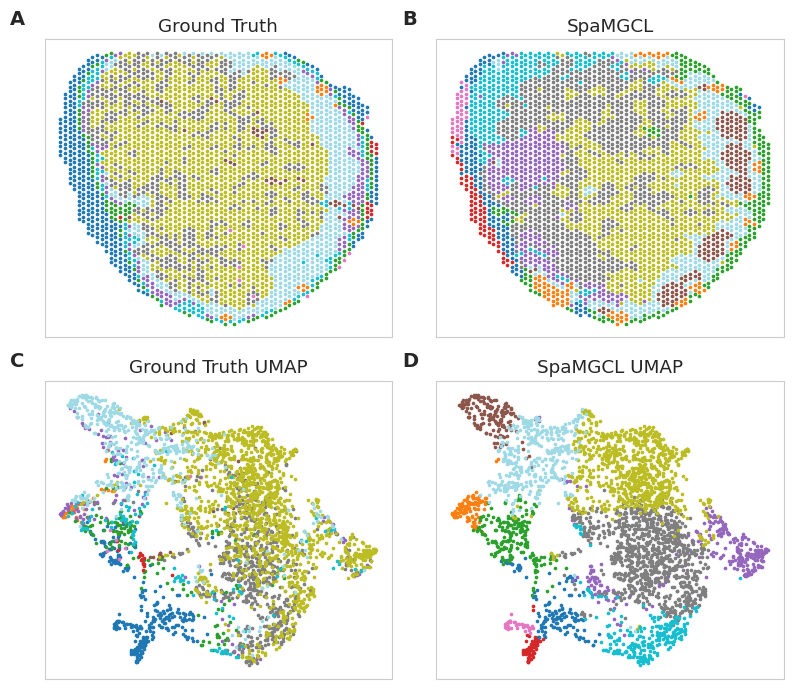

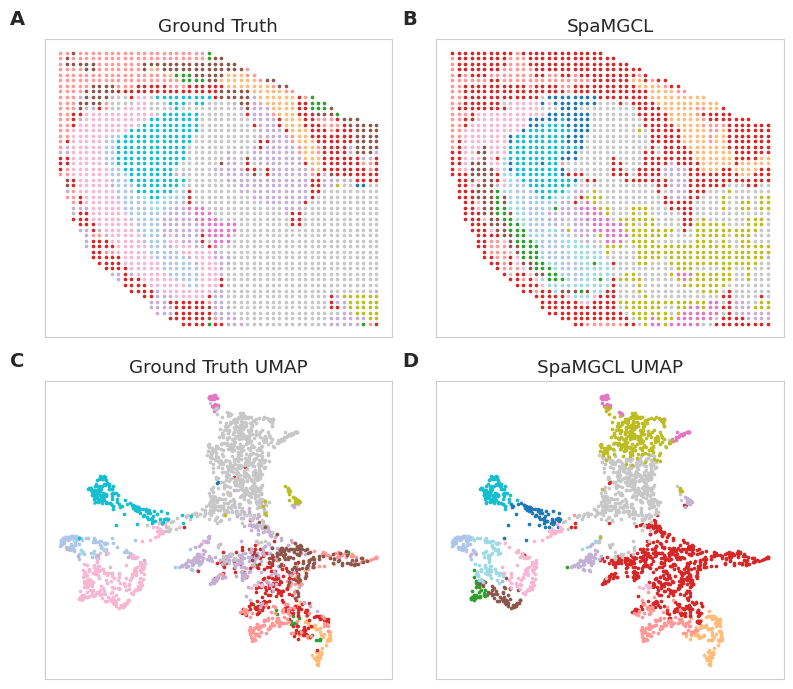

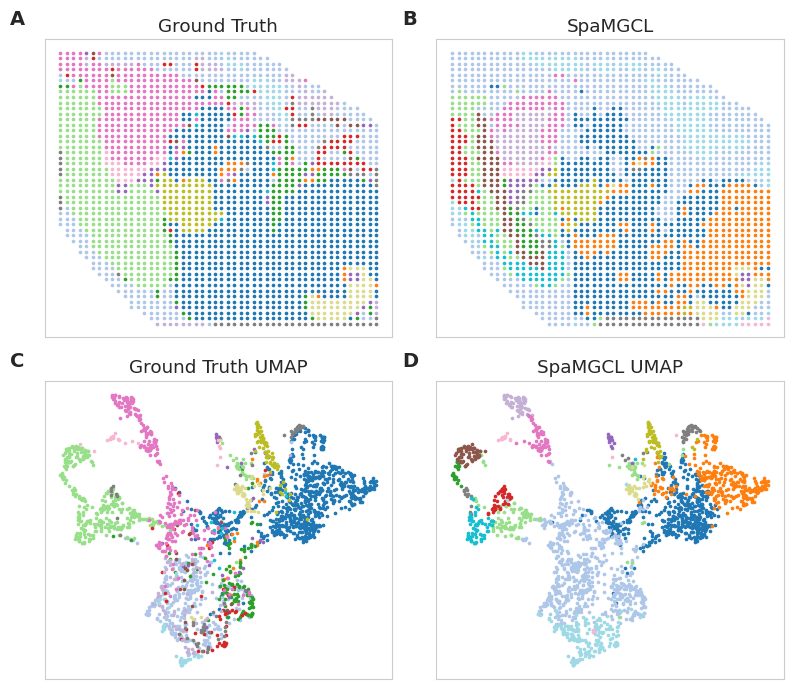

In [24]:
draw_spatial_umap("d1_core_200")
draw_spatial_umap("e185_core_200")
draw_spatial_umap("s2e18_core_200")